# Лекция 4: Механизъм на вниманието (Attention)

## Преговор от Лекция 3

В Лекция 3 разгледахме **токенизацията** — как суровият текст се разбива на токени преди да влезе в модела. Научихме за **BPE (Byte-Pair Encoding)**: алгоритъм, който итеративно слива най-честите двойки, за да изгради речник от поддуми.

За преговор, нека обучим BPE токенизатор върху текст на Иван Вазов и го използваме в следващите примери.

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
print("Библиотеките са заредени.")

Библиотеките са заредени.


Зареждаме корпуса на Иван Вазов — същият текст от предишните лекции.

In [2]:
with open("../data/ivan_vazov.txt", "r") as f:
    raw_text = f.read()

print(f"Дължина на корпуса: {len(raw_text):,} символа")
print(f"Първите 200 символа:")
print(raw_text[:200])

Дължина на корпуса: 3,990,245 символа
Първите 200 символа:
﻿	Иван Вазов
	Драски и шарки

	I част
	Украсил столицата

	Всеки, който го познаваше преди две години, помни как беше съвсем други човек господин Бучински: лек, приятен и весел, винаги в добро разполо


Обучаваме BPE токенизатор с `tokenizers` от HuggingFace. Избираме малък речник от 1000 токена — достатъчно за демонстрация.

In [3]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# Създаваме BPE токенизатор
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

# Обучаваме върху корпуса на Вазов
trainer = BpeTrainer(vocab_size=500, special_tokens=["[UNK]", "[PAD]"])
tokenizer.train_from_iterator([raw_text], trainer=trainer)

print(f"Размер на речника: {tokenizer.get_vocab_size()} токена")




Размер на речника: 500 токена


Да видим как токенизаторът разбива едно изречение от текста.

In [4]:
# Примерно изречение
sample = "Всеки който го познаваше помни как беше съвсем други човек"
encoded = tokenizer.encode(sample)

print(f"Текст:   {sample}")
print(f"Токени:  {encoded.tokens}")
print(f"ID-та:   {encoded.ids}")
print(f"Брой токени: {len(encoded.tokens)}")

Текст:   Всеки който го познаваше помни как беше съвсем други човек
Токени:  ['В', 'се', 'ки', 'който', 'го', 'по', 'зна', 'ваше', 'по', 'м', 'ни', 'как', 'беше', 'съ', 'все', 'м', 'други', 'чове', 'к']
ID-та:   [121, 207, 233, 396, 219, 204, 290, 291, 204, 162, 199, 302, 296, 241, 442, 162, 464, 454, 160]
Брой токени: 19


In [5]:
tokenizer.get_vocab()

{'Бо': 477,
 'щи': 362,
 'нов': 394,
 'у': 169,
 'ваше': 291,
 'не': 206,
 'жи': 264,
 'ълга': 372,
 '[PAD]': 1,
 'f': 61,
 'вете': 461,
 'ня': 244,
 'т': 168,
 'Я': 149,
 'а': 150,
 'и': 158,
 'или': 494,
 'ще': 250,
 'ρ': 113,
 'бе': 232,
 'всич': 363,
 'Z': 51,
 'гу': 471,
 'Д': 123,
 'Ка': 309,
 'госпо': 440,
 'само': 375,
 'п': 165,
 'ги': 285,
 'гра': 320,
 'вя': 332,
 'ча': 253,
 '……': 444,
 'Ма': 408,
 'ф': 170,
 'за': 214,
 'каза': 337,
 'там': 383,
 '.': 11,
 'F': 33,
 'пъ': 453,
 'По': 355,
 'µ': 88,
 '—': 189,
 'B': 29,
 'каз': 449,
 'ник': 397,
 'За': 384,
 'Ц': 141,
 'a': 56,
 'от': 223,
 '–': 188,
 'же': 246,
 'бо': 254,
 'ми': 231,
 'няма': 429,
 'пак': 412,
 'сме': 480,
 'мо': 240,
 'ски': 274,
 'чо': 311,
 'ната': 282,
 'ы': 177,
 '0': 13,
 'про': 270,
 'р': 166,
 'га': 236,
 'У': 138,
 'дру': 308,
 'дна': 361,
 'ваха': 455,
 'Π': 106,
 'му': 247,
 'Но': 344,
 'аз': 323,
 'ти': 235,
 'ба': 265,
 'на': 196,
 'мно': 434,
 'Аз': 423,
 'цата': 425,
 'со': 319,
 'като': 28

Токенизираме по-дълъг фрагмент, който ще използваме в следващите примери.

In [6]:
# Вземаме първите ~500 символа от корпуса
text_fragment = raw_text[1500:2100].strip()
encoded_fragment = tokenizer.encode(text_fragment)

# Запазваме ID-тата като тензор — ще ги ползваме по-нататък
token_ids = torch.tensor(encoded_fragment.ids)
token_strings = encoded_fragment.tokens

print(f"Фрагмент: {text_fragment[:100]}...")
print(f"Брой токени: {len(token_ids)}")
print(f"Първите 15 токена: {token_strings[:15]}")

Фрагмент: Бучински.
	А работата е съвършено проста.
	Господин Бучински има… има… — нека да кажа смело — има но...
Брой токени: 237
Първите 15 токена: ['Б', 'у', 'чи', 'н', 'ски', '.', 'А', 'ра', 'бо', 'тата', 'е', 'съ', 'вър', 'ше', 'но']


---

## Преглед на лекцията

Днес изграждаме разбиране за **механизма на вниманието (attention)** — основния градивен елемент на трансформаторите. Ще видим защо рекурентните мрежи се провалят при дълъг контекст и как вниманието решава този проблем.

**9 блока:**
1. **[Демо]** Преговор + Градиенти в дълбока верига
2. **[Обяснение + Демо]** RNN — Опит за динамичен контекст
3. **[Обяснение]** От RNN към вниманието
4. **[Демо]** Самовнимание (Self-Attention) от нулата
5. **[Обяснение]** Интуиция за Q, K, V
6. **[Обяснение]** Внимание с множество насоки (Multi-Head Attention)
7. **[Демо]** Визуализация на вниманието в GPT-2
8. **[Демо]** Причинна маска и вниманието в nanoGPT
9. **[Дискусия]** Обобщение и въпроси

---

## Блок 1: Обратно разпространение на сигнала (backpropagation) + Градиенти в дълбока верига [Демо]

**Цел:** Да си припомним как се разпространява сигнала през невронната мрежа и да направим изчезващия градиент *осезаем* чрез директно измерване.

В Лекция 2 видяхме как слоят за вграждания (embedding) превръща токени в числови вектори, а мрежата ги обработва слой по слой. Моделът на Бенджо конкатенира вграждания от фиксиран прозорец (3-4 токена) — но какво правим, когато контекстът е цяло изречение или параграф?

Преди да отговорим, нека видим какво се случва с градиентите в дълбока верига от слоеве.

Строим проста верига: вход → линеен слой → tanh → линеен слой → tanh → ... → изход.

In [7]:
# Дълбока верига от 15 слоя
depth = 50
dim = 16

# Тегла с малка инициализация
W_list = [torch.randn(dim, dim) * 0.5 for _ in range(depth)]

x = torch.randn(1, dim, requires_grad=True)
print(f"Вход: {x.shape}, дълбочина: {depth} слоя")

Вход: torch.Size([1, 16]), дълбочина: 50 слоя


Пускаме пряко преминаване (forward pass) и отпечатваме нормите на активациите — те изглеждат нормално.

In [8]:
# Пряко преминаване: записваме активациите на всеки слой
h = x
hiddens = [h]

for W in W_list:
    h = torch.tanh(h @ W)
    h.retain_grad()
    hiddens.append(h)

print("Норми на активациите:")
for i, h_i in enumerate(hiddens[1:], start=1):
    print(f"  Слой {i:2d}: {h_i.norm().item():.4f}")

Норми на активациите:
  Слой  1: 3.2855
  Слой  2: 2.9296
  Слой  3: 3.2414
  Слой  4: 3.0290
  Слой  5: 2.7560
  Слой  6: 3.0537
  Слой  7: 2.8392
  Слой  8: 2.5568
  Слой  9: 3.0423
  Слой 10: 3.0344
  Слой 11: 3.3796
  Слой 12: 3.0126
  Слой 13: 3.0436
  Слой 14: 3.2643
  Слой 15: 3.4387
  Слой 16: 3.3787
  Слой 17: 3.2219
  Слой 18: 2.8600
  Слой 19: 2.8862
  Слой 20: 3.1326
  Слой 21: 3.1119
  Слой 22: 3.2313
  Слой 23: 3.0538
  Слой 24: 3.1646
  Слой 25: 3.0254
  Слой 26: 2.5777
  Слой 27: 2.7159
  Слой 28: 2.8269
  Слой 29: 3.1076
  Слой 30: 3.2422
  Слой 31: 2.9941
  Слой 32: 3.1034
  Слой 33: 2.9333
  Слой 34: 3.1376
  Слой 35: 3.3979
  Слой 36: 3.1616
  Слой 37: 3.0831
  Слой 38: 3.1419
  Слой 39: 3.0994
  Слой 40: 2.8609
  Слой 41: 2.9381
  Слой 42: 2.5841
  Слой 43: 3.1505
  Слой 44: 3.0522
  Слой 45: 3.0511
  Слой 46: 2.9583
  Слой 47: 2.9905
  Слой 48: 2.8423
  Слой 49: 3.0394
  Слой 50: 2.8608


Сега обратно преминаване (backward pass) — измерваме нормите на градиентите на всеки слой.

In [9]:
# Обратно преминаване
loss = hiddens[-1].sum()
loss.backward()

# Събираме нормите на градиентите
grad_norms = [hiddens[i].grad.norm().item() for i in range(1, depth + 1)]

print("Норми на градиентите (1=най-далеч от изхода, 15=изход):")
for i, norm in enumerate(grad_norms, start=1):
    print(f"  Слой {i:2d}: {norm:.6f}")

Норми на градиентите (1=най-далеч от изхода, 15=изход):
  Слой  1: 3.991759
  Слой  2: 4.086162
  Слой  3: 4.605867
  Слой  4: 4.298691
  Слой  5: 2.845837
  Слой  6: 6.448792
  Слой  7: 9.022731
  Слой  8: 7.776790
  Слой  9: 6.397853
  Слой 10: 6.968083
  Слой 11: 10.723816
  Слой 12: 8.508120
  Слой 13: 5.742839
  Слой 14: 6.908991
  Слой 15: 11.261109
  Слой 16: 19.122934
  Слой 17: 21.350140
  Слой 18: 30.352592
  Слой 19: 48.253860
  Слой 20: 37.812702
  Слой 21: 29.286686
  Слой 22: 29.161591
  Слой 23: 32.661423
  Слой 24: 31.238695
  Слой 25: 29.439932
  Слой 26: 21.988798
  Слой 27: 13.018764
  Слой 28: 12.467853
  Слой 29: 24.850702
  Слой 30: 23.454971
  Слой 31: 22.985584
  Слой 32: 22.025286
  Слой 33: 16.845068
  Слой 34: 15.326348
  Слой 35: 28.123545
  Слой 36: 21.464211
  Слой 37: 18.436705
  Слой 38: 16.934387
  Слой 39: 14.218663
  Слой 40: 14.244397
  Слой 41: 13.545524
  Слой 42: 11.876634
  Слой 43: 10.268739
  Слой 44: 6.768423
  Слой 45: 8.378152
  Слой 46: 7.8

Визуализираме спада на градиента.

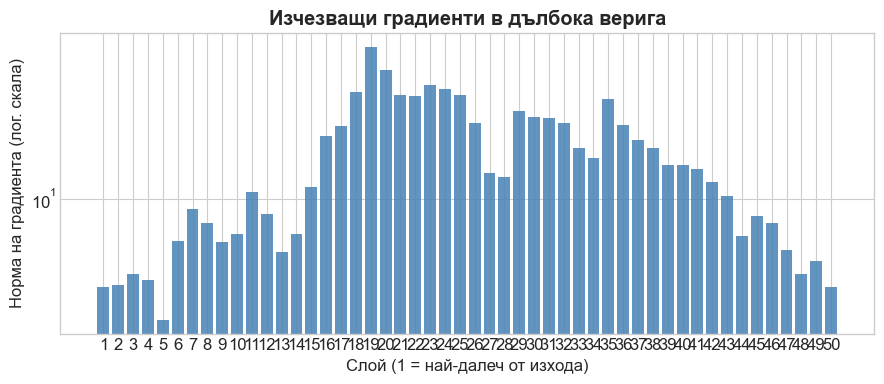

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, depth + 1), grad_norms, color='steelblue', alpha=0.85)
ax.set_xlabel('Слой (1 = най-далеч от изхода)')
ax.set_ylabel('Норма на градиента (лог. скала)')
ax.set_title('Изчезващи градиенти в дълбока верига', fontweight='bold')
ax.set_yscale('log')
ax.set_xticks(range(1, depth + 1))
plt.tight_layout()
plt.show()

Колкото по-далеч е слоят от изхода, толкова по-малък е градиентът. Това е **изчезващият градиент** — при 15 слоя градиентът на входа е стотици пъти по-малък.

Когато "слоевете" са стъпки от токен към токен в рекурентна мрежа, проблемът става критичен — запомнете това.

---

## Блок 2: RNN — Опит за динамичен контекст [Обяснение + Демо]

**Цел:** Да покажем идеята на рекурентната невронна мрежа (RNN) и връзката с изчезващия градиент.

RNN поддържа **скрито състояние** $h$, което се обновява при всеки токен:

$$h_t = \tanh(x_t W_x + h_{t-1} W_h + b)$$

На всяка стъпка моделът може да произведе **изход** — разпределение върху речника:

$$y_t = h_t W_y$$

Едно и също тегло $W_h$ се прилага на *всяка стъпка* — точно като нашата дълбока верига от Блок 1, само че разгърната върху редицата.

![rnn](images/rnn_unrolled.png)

Имплементираме минимална RNN клетка и я пускаме върху токенизирания текст от рекапа.

In [11]:
def rnn_step(x_t, h_prev, W_x, W_h, b):
    """Една стъпка на RNN: h_t = tanh(x_t @ W_x + h_{t-1} @ W_h + b)"""
    return torch.tanh(x_t @ W_x + h_prev @ W_h + b)

print("Функция rnn_step дефинирана.")

Функция rnn_step дефинирана.


Инициализираме теглата и създаваме прости вграждания за нашите токени.

In [12]:
torch.manual_seed(0)

# Размери
vocab_size = tokenizer.get_vocab_size()
embed_dim = 8
hidden_dim = 8

# Прост слой за вграждания (с градиенти)
embedding = torch.randn(vocab_size, embed_dim) * 0.1

# Тегла на RNN (с градиенти)
W_x = torch.randn(embed_dim, hidden_dim, requires_grad=True) * 0.5
W_h = torch.randn(hidden_dim, hidden_dim, requires_grad=True) * 1.5  # голяма инициализация → tanh в наситена зона
b = torch.zeros(1, hidden_dim, requires_grad=True)

# Изходен слой: от скрито състояние → логити върху речника
W_y = torch.randn(hidden_dim, vocab_size, requires_grad=True) * 0.3

print(f"Embedding: {embedding.shape}")
print(f"W_x: {W_x.shape}, W_h: {W_h.shape}")
print(f"W_y: {W_y.shape} (скрито състояние → речник)")
print(f"W_h инициализация: * 1.5 (за да наситим tanh → изчезващ градиент)")

Embedding: torch.Size([500, 8])
W_x: torch.Size([8, 8]), W_h: torch.Size([8, 8])
W_y: torch.Size([8, 500]) (скрито състояние → речник)
W_h инициализация: * 1.5 (за да наситим tanh → изчезващ градиент)


Пускаме RNN върху първите 50 токена от текста на Вазов.

In [13]:
# Вземаме първите 50 токена — достатъчно дълга редица за ефекта
T = 50
ids = token_ids[:T]
tokens_used = token_strings[:T]

# Вграждаме ги (float тензори с grad tracking)
xs = [embedding[id].unsqueeze(0).requires_grad_(True) for id in ids]

print(f"Токени: {tokens_used[:10]}...")
print(f"Брой стъпки: {T}")

Токени: ['Б', 'у', 'чи', 'н', 'ски', '.', 'А', 'ра', 'бо', 'тата']...
Брой стъпки: 50


In [14]:
# Пускаме RNN стъпка по стъпка
h = torch.zeros(1, hidden_dim, requires_grad=True)
hiddens_rnn = [h]
logits_rnn = []

for t, x_t in enumerate(xs):
    h = rnn_step(x_t, hiddens_rnn[-1], W_x, W_h, b)
    h.retain_grad()
    hiddens_rnn.append(h)
    # Изход: логити върху речника
    logits_t = h @ W_y  # (1, vocab_size)
    logits_rnn.append(logits_t)

print("Норми на скритото състояние:")
for t in range(1, T + 1, 10):
    print(f"  t={t:2d} ({tokens_used[t-1]:>10s}): norm(h) = {hiddens_rnn[t].norm().item():.4f}")

Норми на скритото състояние:
  t= 1 (         Б): norm(h) = 0.2402
  t=11 (         е): norm(h) = 2.6340
  t=21 (       дин): norm(h) = 2.5092
  t=31 (         —): norm(h) = 2.6993
  t=41 (        но): norm(h) = 2.6878


На всяка стъпка RNN произвежда логити $y_t = h_t W_y$ — разпределение върху речника. Да видим какво "предсказва" необучената мрежа.

In [15]:
# На всяка стъпка: логити → softmax → предсказан токен
print(f"{'Стъпка':>8s}  {'Вход':>10s} → {'Предсказан':>10s}  {'Реален':>10s}  {'P(реален)':>10s}")
print("-" * 65)

for t in range(T - 1):
    probs = F.softmax(logits_rnn[t], dim=-1)
    pred_id = probs.argmax(dim=-1).item()
    pred_token = tokenizer.id_to_token(pred_id)
    actual_token = tokens_used[t + 1]
    actual_id = ids[t + 1].item()
    actual_prob = probs[0, actual_id].item()

    if t < 15 or t >= T - 5:
        print(f"  t={t+1:2d}    {tokens_used[t]:>10s} → {pred_token:>10s}  {actual_token:>10s}  {actual_prob:>10.4f}")
    elif t == 15:
        print(f"  {'...':>50s}")

print(f"\nМоделът не е обучен — предсказанията са случайни (1/{vocab_size} ≈ {1/vocab_size:.4f}).")

  Стъпка        Вход → Предсказан      Реален   P(реален)
-----------------------------------------------------------------
  t= 1             Б →          У           у      0.0019
  t= 2             у →       вече          чи      0.0016
  t= 3            чи →        слу           н      0.0022
  t= 4             н →       вече         ски      0.0017
  t= 5           ски →          ¤           .      0.0011
  t= 6             . →         се           А      0.0010
  t= 7             А →       ство          ра      0.0026
  t= 8            ра →        сни          бо      0.0016
  t= 9            бо →       вече        тата      0.0031
  t=10          тата →        кои           е      0.0020
  t=11             е →          …          съ      0.0025
  t=12            съ →          …         вър      0.0009
  t=13           вър →       рите          ше      0.0009
  t=14            ше →         се          но      0.0005
  t=15            но →         се         про      0.0010
      

Скритите състояния изглеждат добре. Но какво става с градиентите?

In [16]:
# Обратно преминаване
loss_rnn = hiddens_rnn[-1].sum()
loss_rnn.backward()

# Градиенти по стъпки
rnn_grad_norms = [hiddens_rnn[t].grad.norm().item() for t in range(1, T + 1)]

print("Норми на градиентите по стъпки (избрани):")
for t in [1, 5, 10, 15, 20, 30, 40, 50]:
    tok = tokens_used[t-1]
    print(f"  t={t:2d} ({tok:>10s}): {rnn_grad_norms[t-1]:.6f}")

Норми на градиентите по стъпки (избрани):
  t= 1 (         Б): 1385.680786
  t= 5 (       ски): 91.738815
  t=10 (      тата): 24.991293
  t=15 (        но): 14.405956
  t=20 (       спо): 26.734686
  t=30 (         …): 154.919769
  t=40 (       има): 4.577319
  t=50 (       три): 2.828427


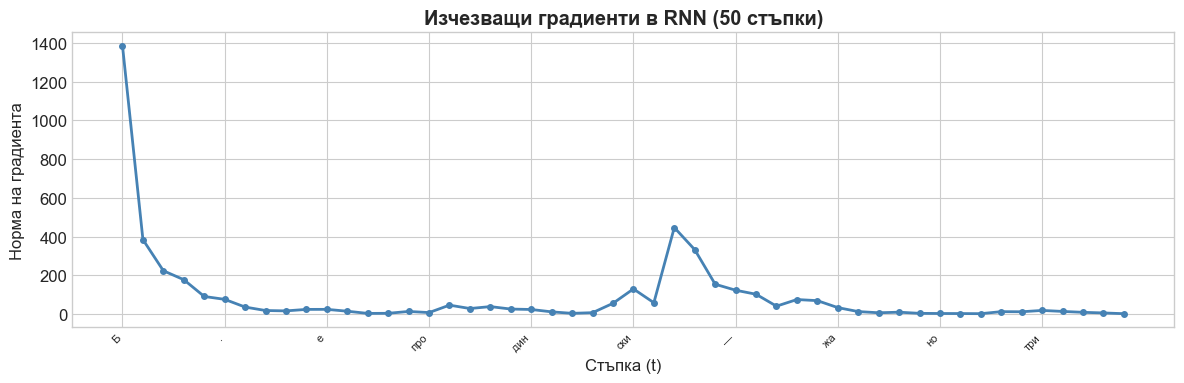

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(1, T + 1), rnn_grad_norms, 'o-', color='steelblue', linewidth=2, markersize=4)
ax.set_xlabel('Стъпка (t)')
ax.set_ylabel('Норма на градиента')
ax.set_title('Изчезващи градиенти в RNN (50 стъпки)', fontweight='bold')

# Показваме всеки 5-ти токен за четимост
tick_positions = list(range(0, T, 5))
ax.set_xticks([p + 1 for p in tick_positions])
ax.set_xticklabels([tokens_used[i] for i in tick_positions], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

---

## Блок 3: От RNN към вниманието [Обяснение]

**Цел:** Концептуалният мост — как оставяме всеки токен да "вижда" директно всеки друг?

Основният проблем: в RNN, токен 1 стига до токен 50 през **49 скрити стъпки**. Видяхме какво се случва с градиентите дори при 20 стъпки.

![tokens](images/self_attn_int.png)

**Какво ако всеки токен може директно да разглежда всеки друг токен?** Без верига, без последователност.

Идеята: изчисляваме **оценка за релевантност** между всяка двойка токени, използваме оценките за смесване на информацията. Токен на позиция 50 може директно да "потърси" свързания токен на позиция 1 — без да минава през 49 стъпки.

Това е **вниманието (attention)**: претеглена сума на всички позиции, където теглата се изчисляват на базата на съдържанието.

---

## Блок 4: Самовнимание (Self-Attention) от нулата [Демо]

**Цел:** Строим самовнимание (self-attention) стъпка по стъпка върху малка редица от токени.

Вземаме 6 токена от нашия текст на Вазов и ги вграждаме в 4-измерно пространство — достатъчно малко, за да отпечатаме всяка матрица.

In [18]:
token_strings[6:15]

['А', 'ра', 'бо', 'тата', 'е', 'съ', 'вър', 'ше', 'но']

In [19]:
torch.manual_seed(7)

# Вземаме 6 токена от текста на Вазов
T_attn = 9
d_model = 4

selected_tokens = token_strings[6:15]  #token_strings[:T_attn]
print(f"Токени: {selected_tokens}")

Токени: ['А', 'ра', 'бо', 'тата', 'е', 'съ', 'вър', 'ше', 'но']


**Стъпка 1:** Създаваме входните вграждания $X$ — в практиката те идват от слоя за вграждания (embedding).

In [20]:
# Случайни вграждания (в практиката: от слоя за вграждания)
X = torch.randn(T_attn, d_model)

print(f"X (входни вграждания): форма {X.shape}")
print(f"{T_attn} токена × {d_model} измерения\n")
print(X.round(decimals=3))

X (входни вграждания): форма torch.Size([9, 4])
9 токена × 4 измерения

tensor([[-0.8200,  0.3960,  0.8990, -1.3880],
        [-0.1670,  0.2850, -0.6410, -0.8940],
        [ 0.9270, -0.5360, -1.1600, -0.4600],
        [ 0.7090,  1.0130,  0.2300,  1.0900],
        [-1.5830, -0.3250,  1.9260, -0.3300],
        [ 0.9570, -0.6620, -0.8280, -0.6060],
        [-0.1350,  0.7470,  0.6120,  1.8680],
        [-0.2620, -0.2500,  0.5010,  0.2600],
        [-1.6370,  0.1580,  0.3960, -1.3680]])


**Стъпка 2:** Дефинираме три проекционни матрици — $W_Q$, $W_K$, $W_V$. Всяка трансформира входа в различно "пространство".

In [21]:
d_k = 4  # размерност на запитване/ключ/стойност

W_Q = torch.randn(d_model, d_k)
W_K = torch.randn(d_model, d_k)
W_V = torch.randn(d_model, d_k)

print(f"W_Q: {W_Q.shape}")
print(f"W_K: {W_K.shape}")
print(f"W_V: {W_V.shape}")

W_Q: torch.Size([4, 4])
W_K: torch.Size([4, 4])
W_V: torch.Size([4, 4])


**Стъпка 3:** Изчисляваме $Q = XW_Q$, $K = XW_K$, $V = XW_V$.

In [22]:
Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print(f"Q (запитвания): {Q.shape}")
print(Q.round(decimals=3))

Q (запитвания): torch.Size([9, 4])
tensor([[ 2.3530,  0.2650, -2.1600, -2.3890],
        [-0.9640,  0.2180, -1.0580, -2.1300],
        [-4.1890,  0.1520, -0.8110, -0.5610],
        [-1.4720, -2.1790,  1.8250,  2.2250],
        [ 6.7960,  1.3690, -0.8450, -0.4410],
        [-3.9530,  0.1610, -1.2180, -0.4710],
        [ 2.1060, -1.2310,  3.1070,  3.0260],
        [ 1.6250,  0.3400,  0.2310,  0.6200],
        [ 4.3050,  1.5980, -1.7820, -3.4240]])


In [23]:
print(f"K (ключове): {K.shape}")
print(K.round(decimals=3))

K (ключове): torch.Size([9, 4])
tensor([[ 1.9520,  0.7540, -1.7440, -1.7830],
        [ 1.8450,  0.3550, -0.0870, -2.1620],
        [-0.6920, -1.6440,  0.6610, -0.6680],
        [-0.3220, -0.2730, -0.4830, -1.1100],
        [ 0.1500,  1.6500, -1.1150,  2.4010],
        [-1.0850, -1.9570,  0.2710, -0.4020],
        [-0.5820,  1.1750,  0.3630,  1.3150],
        [-0.6660,  0.2080, -0.0140,  1.3880],
        [ 2.9920,  2.2180, -0.5790, -1.0060]])


In [24]:
print(f"V (стойности): {V.shape}")
print(V.round(decimals=3))

V (стойности): torch.Size([9, 4])
tensor([[-2.0790,  3.7650, -0.2450,  1.2830],
        [-0.3640,  1.9320, -0.1390, -0.5380],
        [ 0.0900, -1.3160,  1.3430, -0.8110],
        [ 1.3950, -0.5260,  0.6650,  1.0590],
        [-1.9050,  1.7640, -1.5960,  1.1660],
        [-0.4080, -1.2910,  1.6540, -0.3110],
        [ 1.9750, -1.3200, -1.0340,  0.2980],
        [-0.1830, -0.5090, -0.3310,  0.2140],
        [-1.6340,  4.0130, -1.9200, -0.3620]])


**Стъпка 4:** Изчисляваме суровите оценки за внимание — скаларно произведение (dot product) на $Q$ и $K^T$. Резултатът е матрица $T \times T$: за всяка двойка токени.

In [25]:
scores = Q @ K.T  # (T, T)

print(f"Scores = Q @ K.T: форма {scores.shape}")
print(f"Всеки токен срещу всеки токен:\n")
print(scores.round(decimals=3))

Scores = Q @ K.T: форма torch.Size([9, 9])
Всеки токен срещу всеки токен:

tensor([[ 12.8190,   9.7880,  -1.8970,   2.8660,  -2.5370,  -2.6970,  -4.9840,
          -4.7980,  11.2800],
        [  3.9250,   2.9950,   1.0320,   3.1270,  -3.7180,   1.1890,  -2.3670,
          -2.2550,   0.3540],
        [ -5.6480,  -6.3930,   2.4890,   2.3240,  -0.8190,   4.2540,   1.5850,
           2.0530, -11.1620],
        [-11.6660,  -8.4590,   4.3220,  -2.2830,  -0.5100,   5.4630,   1.8840,
           3.5910, -12.5310],
        [ 16.5580,  14.0540,  -7.2200,  -1.6660,   3.1620, -10.1060,  -3.2340,
          -4.8410,  24.3010],
        [ -4.6290,  -6.1120,   1.9800,   2.3410,  -0.0970,   3.8320,   1.4290,
           2.0280, -10.2880],
        [ -7.6330,  -3.3640,   0.6000,  -5.2040,   2.0830,  -0.2490,   2.4350,
           2.5010,  -1.2750],
        [  1.9190,   1.7590,  -1.9460,  -1.4170,   2.0360,  -2.6160,   0.3530,
          -0.1540,   4.8580],
        [ 18.8220,  16.0690,  -4.5000,   2.8400,  -2.

**Стъпка 5:** Мащабираме с $\frac{1}{\sqrt{d_k}}$.

Защо? При голям $d_k$ скаларните произведения растат по величина. Softmax на големи числа дава вектори близки до one-hot — градиентите стават почти нулеви. Мащабирането стабилизира стойностите.

In [26]:
scores_scaled = scores / math.sqrt(d_k)

print(f"Мащабиране с 1/√{d_k} = {1/math.sqrt(d_k):.3f}")
print(f"\nScores след мащабиране:")
print(scores_scaled.round(decimals=3))

Мащабиране с 1/√4 = 0.500

Scores след мащабиране:
tensor([[ 6.4100,  4.8940, -0.9480,  1.4330, -1.2680, -1.3480, -2.4920, -2.3990,
          5.6400],
        [ 1.9620,  1.4970,  0.5160,  1.5640, -1.8590,  0.5940, -1.1830, -1.1280,
          0.1770],
        [-2.8240, -3.1960,  1.2450,  1.1620, -0.4100,  2.1270,  0.7920,  1.0260,
         -5.5810],
        [-5.8330, -4.2300,  2.1610, -1.1420, -0.2550,  2.7310,  0.9420,  1.7960,
         -6.2660],
        [ 8.2790,  7.0270, -3.6100, -0.8330,  1.5810, -5.0530, -1.6170, -2.4210,
         12.1500],
        [-2.3140, -3.0560,  0.9900,  1.1710, -0.0490,  1.9160,  0.7140,  1.0140,
         -5.1440],
        [-3.8170, -1.6820,  0.3000, -2.6020,  1.0410, -0.1240,  1.2170,  1.2500,
         -0.6380],
        [ 0.9600,  0.8790, -0.9730, -0.7080,  1.0180, -1.3080,  0.1770, -0.0770,
          2.4290],
        [ 9.4110,  8.0340, -2.2500,  1.4200, -1.4760, -3.4530, -2.8890, -3.6320,
         10.4500]])


**Стъпка 6:** Softmax — превръщаме оценките в тегла, които сумират до 1 за всеки ред.

In [27]:
attn_weights = F.softmax(scores_scaled, dim=-1)

print("Тегла на вниманието (softmax):")
print(attn_weights.round(decimals=3))
print(f"\nВсеки ред сумира до: {attn_weights.sum(dim=-1).round(decimals=3)}")

Тегла на вниманието (softmax):
tensor([[0.5910, 0.1300, 0.0000, 0.0040, 0.0000, 0.0000, 0.0000, 0.0000, 0.2740],
        [0.3260, 0.2050, 0.0770, 0.2190, 0.0070, 0.0830, 0.0140, 0.0150, 0.0550],
        [0.0030, 0.0020, 0.1670, 0.1530, 0.0320, 0.4030, 0.1060, 0.1340, 0.0000],
        [0.0000, 0.0000, 0.2570, 0.0090, 0.0230, 0.4550, 0.0760, 0.1790, 0.0000],
        [0.0200, 0.0060, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.9740],
        [0.0050, 0.0030, 0.1450, 0.1730, 0.0510, 0.3650, 0.1100, 0.1480, 0.0000],
        [0.0020, 0.0150, 0.1060, 0.0060, 0.2220, 0.0690, 0.2650, 0.2740, 0.0410],
        [0.1170, 0.1080, 0.0170, 0.0220, 0.1240, 0.0120, 0.0530, 0.0410, 0.5070],
        [0.2450, 0.0620, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.6930]])

Всеки ред сумира до: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1.])


**Стъпка 7:** Крайният изход — претеглена сума на стойностите $V$.

In [28]:
output = attn_weights @ V

print(f"Изход: {output.shape} → {T_attn} токена × {d_k} измерения")
print(output.round(decimals=3))

Изход: torch.Size([9, 4]) → 9 токена × 4 измерения
tensor([[-1.7180e+00,  3.5730e+00, -6.8500e-01,  5.9400e-01],
        [-5.5200e-01,  1.5060e+00,  1.4200e-01,  4.4800e-01],
        [ 1.8200e-01, -9.5700e-01,  7.8600e-01,  2.0000e-03],
        [-7.6000e-02, -1.0810e+00,  9.3000e-01, -2.5200e-01],
        [-1.6360e+00,  3.9960e+00, -1.8750e+00, -3.2900e-01],
        [ 1.8500e-01, -8.5700e-01,  6.6700e-01,  8.2000e-02],
        [-3.8000e-02, -1.2800e-01, -5.4100e-01,  2.7500e-01],
        [-1.2200e+00,  2.7570e+00, -1.2250e+00,  8.3000e-02],
        [-1.6640e+00,  3.8230e+00, -1.3990e+00,  3.1000e-02]])


Визуализираме теглата на вниманието — кой токен колко "гледа" към всеки друг.

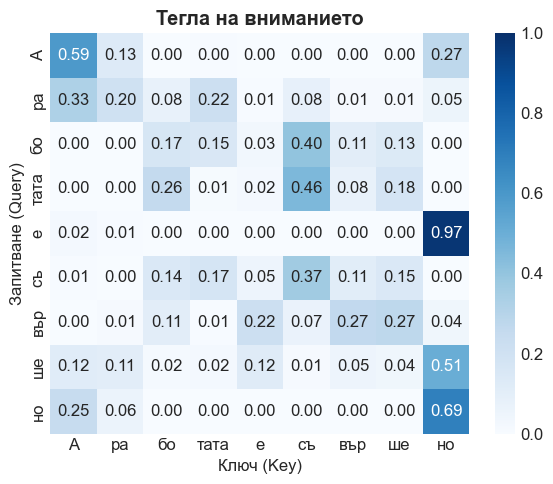

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    attn_weights.detach().numpy(),
    annot=True, fmt=".2f", cmap="Blues",
    xticklabels=selected_tokens,
    yticklabels=selected_tokens,
    ax=ax, vmin=0, vmax=1
)
ax.set_title("Тегла на вниманието", fontweight='bold')
ax.set_xlabel("Ключ (Key)")
ax.set_ylabel("Запитване (Query)")
plt.tight_layout()
plt.show()

Всяка клетка показва колко внимание токенът-ред отдава на токена-колона. По-тъмно = повече внимание.

---

## Блок 5: Интуиция за Q, K, V [Обяснение]

**Цел:** Защо три отделни проекции, а не просто скаларно произведение на суровите вграждания?

**Без Q/K/V:** оценката за внимание = скаларно произведение на суровите вграждания. Токенът има едно фиксирано представяне и за "какво търся" и за "какво предлагам" — твърде ограничено.

**С Q/K/V:** един токен може да *пита* за едно (Q), докато *рекламира* друго (K) и *допринася* трето (V).

- **Q (запитване, Query)** — "какво търся?"
- **K (ключ, Key)** — "какво предлагам за съпоставяне?"
- **V (стойност, Value)** — "каква информация давам, ако ме изберат?"

Пример: глагол може да търси своя подлог (Q), докато обявява, че е действие (K). Стойността (V) е отделна — това, което *предоставяш*, не е задължително същото като това, *по което те разпознават*.

![self-attn](images/self-attention-bg.png)

Да илюстрираме разликата — attention без и с Q/K/V проекции.

In [30]:
# Без Q/K/V: директно скаларно произведение на суровите вграждания
scores_raw = X @ X.T / math.sqrt(d_model)
attn_raw = F.softmax(scores_raw, dim=-1)

# С Q/K/V: проекциите, които вече изчислихме
attn_qkv = attn_weights  # от Блок 4

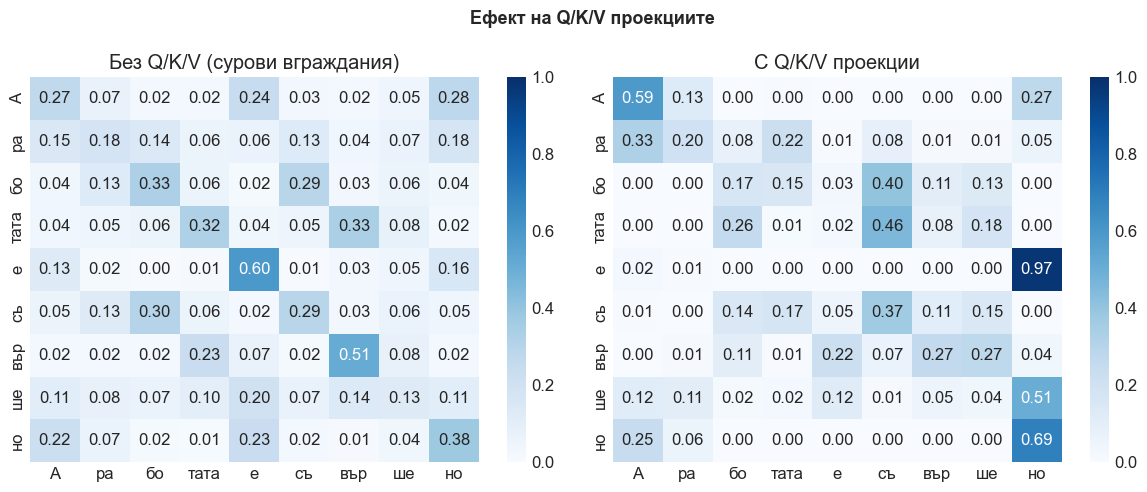

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(attn_raw.detach().numpy(), annot=True, fmt=".2f", cmap="Blues",
            xticklabels=selected_tokens, yticklabels=selected_tokens,
            ax=axes[0], vmin=0, vmax=1)
axes[0].set_title("Без Q/K/V (сурови вграждания)")

sns.heatmap(attn_qkv.detach().numpy(), annot=True, fmt=".2f", cmap="Blues",
            xticklabels=selected_tokens, yticklabels=selected_tokens,
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("С Q/K/V проекции")

plt.suptitle("Ефект на Q/K/V проекциите", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

Без Q/K/V теглата са по-симетрични и по-равномерни. С Q/K/V моделът може да научи по-специализирани модели на внимание.

---


---

## Блок 6: Внимание с множество насоки (Multi-Head Attention) [Обяснение]

**Цел:** Защо множество глави и как работят.

Една глава = един "въпрос", който моделът задава на всяка позиция.

Множество глави = паралелни въпроси:
- "Кой е моят подлог?"
- "Кое прилагателно ме модифицира?"
- "Кой токен дойде точно преди мен?"

**Механика:** разделяме `d_model` на `h` глави по `d_k = d_model / h`, изпълняваме вниманието независимо, конкатенираме, проецираме обратно.

![mult-head](images/multi_headed.png)

Да видим как размерите се разделят по глави.

In [32]:
d_model_full = 64
n_heads = 4
d_k_per_head = d_model_full // n_heads

print(f"d_model = {d_model_full}")
print(f"Брой глави = {n_heads}")
print(f"d_k на глава = {d_model_full} / {n_heads} = {d_k_per_head}")

d_model = 64
Брой глави = 4
d_k на глава = 64 / 4 = 16


Симулираме multi-head attention: проецираме, разделяме по глави, показваме формите.

In [33]:
# Вземаме 8 токена от текста на Вазов
B = 1          # партида (batch)
T_demo = 8     # дължина на редицата
d_m = d_model_full

# Случайни вграждания за демонстрация
X_demo = torch.randn(B, T_demo, d_m)

print(f"Вход: {X_demo.shape} → (партида, токени, d_model)")

Вход: torch.Size([1, 8, 64]) → (партида, токени, d_model)


In [34]:
# Проекция Q (единична матрица за Q, K, V наведнъж)
W_Q_full = torch.randn(d_m, d_m)
Q_full = X_demo @ W_Q_full

print(f"Q преди разделяне: {Q_full.shape}")

Q преди разделяне: torch.Size([1, 8, 64])


In [35]:
# Разделяме по глави: (B, T, d_model) → (B, T, n_heads, d_k) → (B, n_heads, T, d_k)
Q_heads = Q_full.view(B, T_demo, n_heads, d_k_per_head).transpose(1, 2)

print(f"Q след разделяне: {Q_heads.shape}")
print(f"  → (партида={B}, глави={n_heads}, токени={T_demo}, d_k={d_k_per_head})")
print(f"\nВсяка глава работи с {d_k_per_head}-мерни вектори независимо.")

Q след разделяне: torch.Size([1, 4, 8, 16])
  → (партида=1, глави=4, токени=8, d_k=16)

Всяка глава работи с 16-мерни вектори независимо.


Всяка глава "вижда" различна 16-мерна проекция на токените и може да научи различна стратегия за внимание. В Блок 7 ще видим, че в GPT-2 различните глави наистина научават различни модели.

---

## Блок 7: Визуализация на вниманието в GPT-2 [Демо]

**Цел:** Да видим реални тегла на вниманието в модел, който познаваме от Лекция 1.

Зареждаме GPT-2 и разглеждаме как различните глави в различните слоеве разпределят вниманието.

In [36]:
from transformers import GPT2Model, GPT2Tokenizer

gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_model = GPT2Model.from_pretrained('gpt2', output_attentions=True)
gpt2_model.eval()

print(f"Брой слоеве: {gpt2_model.config.n_layer}")
print(f"Брой глави на слой: {gpt2_model.config.n_head}")
print(f"d_model: {gpt2_model.config.n_embd}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Брой слоеве: 12
Брой глави на слой: 12
d_model: 768


In [37]:
gpt2_model

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)

Подаваме изречение и извличаме attention теглата.

In [38]:
text_gpt2 = "The day was long but she decided to stay home anyway."
inputs = gpt2_tokenizer(text_gpt2, return_tensors='pt')
gpt2_tokens = gpt2_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

with torch.no_grad():
    outputs = gpt2_model(**inputs)

attentions = outputs.attentions

print(f"Токени: {gpt2_tokens}")
print(f"Брой слоеве: {len(attentions)}")
print(f"Форма за слой: {attentions[0].shape} → (партида, глави, T, T)")
# Ġ - репрезентатира интервал в BPE

Токени: ['The', 'Ġday', 'Ġwas', 'Ġlong', 'Ġbut', 'Ġshe', 'Ġdecided', 'Ġto', 'Ġstay', 'Ġhome', 'Ġanyway', '.']
Брой слоеве: 12
Форма за слой: torch.Size([1, 12, 12, 12]) → (партида, глави, T, T)


In [39]:
len(attentions), attentions[0].shape

(12, torch.Size([1, 12, 12, 12]))

Визуализираме две глави от един и същи слой — ще видим, че научават различни стратегии.

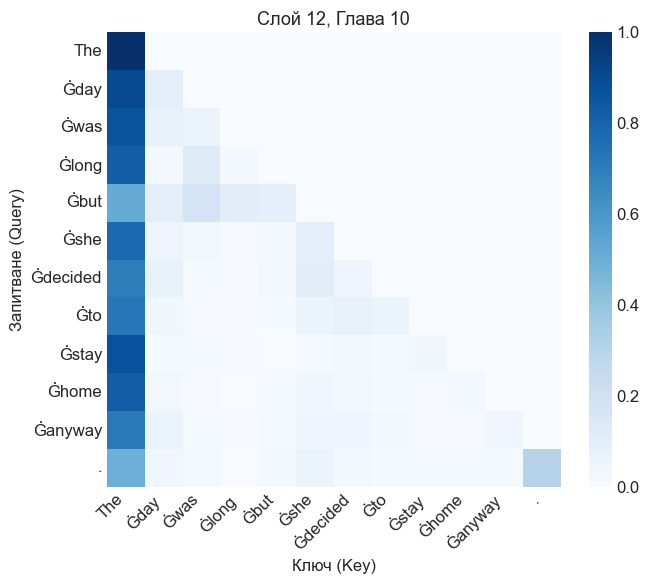

In [40]:
# Слой 1, глава 1
layer_idx = 11
head_idx = 10
attn_matrix = attentions[layer_idx][0, head_idx].numpy()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(attn_matrix, xticklabels=gpt2_tokens, yticklabels=gpt2_tokens,
            cmap='Blues', ax=ax, vmin=0, vmax=attn_matrix.max())
ax.set_title(f'Слой {layer_idx+1}, Глава {head_idx}', fontsize=13)
ax.set_xlabel('Ключ (Key)')
ax.set_ylabel('Запитване (Query)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

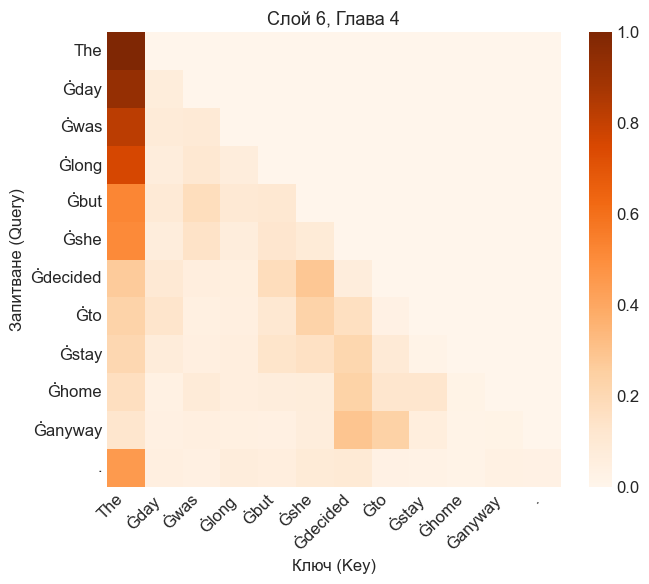

In [41]:
# Слой 6, глава 4 — различен модел
layer_idx = 5
head_idx2 = 3
attn_matrix2 = attentions[layer_idx][0, head_idx2].numpy()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(attn_matrix2, xticklabels=gpt2_tokens, yticklabels=gpt2_tokens,
            cmap='Oranges', ax=ax, vmin=0, vmax=attn_matrix2.max())
ax.set_title(f'Слой {layer_idx+1}, Глава 4', fontsize=13)
ax.set_xlabel('Ключ (Key)')
ax.set_ylabel('Запитване (Query)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Двете глави показват различни модели на внимание — една може да гледа към съседни токени, друга — към семантично свързани позиции.

**Всяка глава е научила различна стратегия самостоятелно** — без изрични инструкции.

Да видим и ранен слой — слой 1 обикновено показва по-прости модели (напр. "гледай предишния токен").

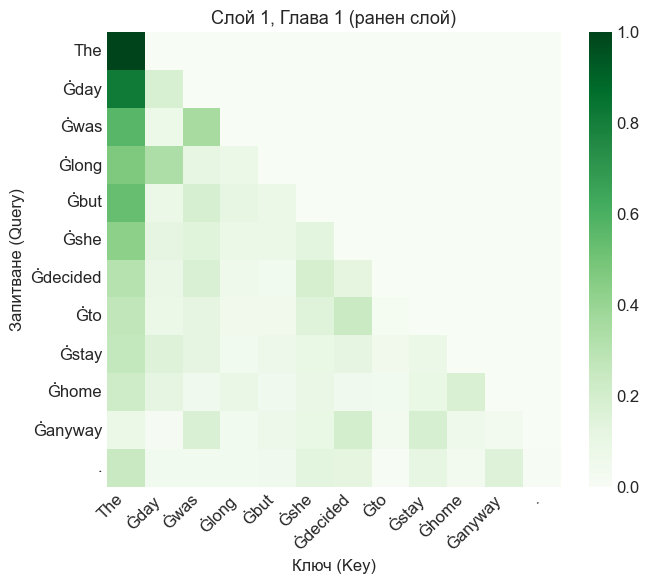

In [42]:
# Слой 1, глава 1 — типично: "гледай предишния токен"
attn_early = attentions[0][0, 0].numpy()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(attn_early, xticklabels=gpt2_tokens, yticklabels=gpt2_tokens,
            cmap='Greens', ax=ax, vmin=0, vmax=attn_early.max())
ax.set_title(f'Слой 1, Глава 1 (ранен слой)', fontsize=13)
ax.set_xlabel('Ключ (Key)')
ax.set_ylabel('Запитване (Query)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Ранните слоеве обикновено показват по-локални модели (предишен/следващ токен), докато по-дълбоките слоеве улавят по-сложни семантични връзки.

---

## Блок 8: Причинна маска и вниманието в nanoGPT [Демо]

**Цел:** Причинната маска и нейното приложение в реален код.

При езиково моделиране токен на позиция $t$ може да гледа само **назад** — не трябва да вижда бъдещите токени. **Причинната маска (causal mask)** прилага това ограничение: позициите над диагонала се запълват с $-\infty$ преди softmax.

Визуализираме причинната маска.

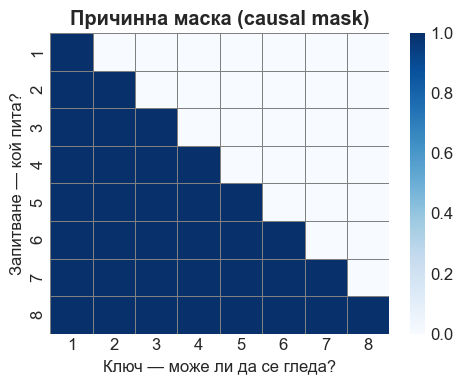

In [43]:
T_mask = 8
causal_mask = torch.tril(torch.ones(T_mask, T_mask))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(causal_mask.numpy(), cmap='Blues', ax=ax,
            xticklabels=range(1, T_mask+1), yticklabels=range(1, T_mask+1),
            linewidths=0.5, linecolor='gray', vmin=0, vmax=1)
ax.set_title("Причинна маска (causal mask)", fontweight='bold')
ax.set_xlabel("Ключ — може ли да се гледа?")
ax.set_ylabel("Запитване — кой пита?")
plt.tight_layout()
plt.show()

Долният триъгълник е 1 (разрешено), горният е 0 (забранено). Токен 3 може да гледа токени 1, 2, 3, но не 4, 5, 6...

Прилагаме маската върху нашия toy attention от Блок 4.

In [44]:
# Маскираме горния триъгълник с -inf
scores_masked = scores_scaled.clone()
mask = torch.tril(torch.ones(T_attn, T_attn))
scores_masked = scores_masked.masked_fill(mask == 0, float('-inf'))

print("Scores след маскиране:")
print(scores_masked.round(decimals=3))

Scores след маскиране:
tensor([[ 6.4100,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,
            -inf],
        [ 1.9620,  1.4970,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,
            -inf],
        [-2.8240, -3.1960,  1.2450,    -inf,    -inf,    -inf,    -inf,    -inf,
            -inf],
        [-5.8330, -4.2300,  2.1610, -1.1420,    -inf,    -inf,    -inf,    -inf,
            -inf],
        [ 8.2790,  7.0270, -3.6100, -0.8330,  1.5810,    -inf,    -inf,    -inf,
            -inf],
        [-2.3140, -3.0560,  0.9900,  1.1710, -0.0490,  1.9160,    -inf,    -inf,
            -inf],
        [-3.8170, -1.6820,  0.3000, -2.6020,  1.0410, -0.1240,  1.2170,    -inf,
            -inf],
        [ 0.9600,  0.8790, -0.9730, -0.7080,  1.0180, -1.3080,  0.1770, -0.0770,
            -inf],
        [ 9.4110,  8.0340, -2.2500,  1.4200, -1.4760, -3.4530, -2.8890, -3.6320,
         10.4500]])


In [45]:
# Softmax — -inf позициите стават 0
attn_weights_causal = F.softmax(scores_masked, dim=-1)

print("Тегла с причинна маска:")
print(attn_weights_causal.round(decimals=3))
print("\nГорният триъгълник е 0 — токените не виждат напред.")

Тегла с причинна маска:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.6140, 0.3860, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0170, 0.0110, 0.9720, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0020, 0.9630, 0.0350, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7770, 0.2220, 0.0000, 0.0000, 0.0010, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0070, 0.0030, 0.1950, 0.2340, 0.0690, 0.4920, 0.0000, 0.0000, 0.0000],
        [0.0030, 0.0210, 0.1550, 0.0080, 0.3250, 0.1010, 0.3870, 0.0000, 0.0000],
        [0.2360, 0.2180, 0.0340, 0.0450, 0.2500, 0.0240, 0.1080, 0.0840, 0.0000],
        [0.2450, 0.0620, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.6930]])

Горният триъгълник е 0 — токените не виждат напред.


Сравняваме визуално теглата без и с маска.

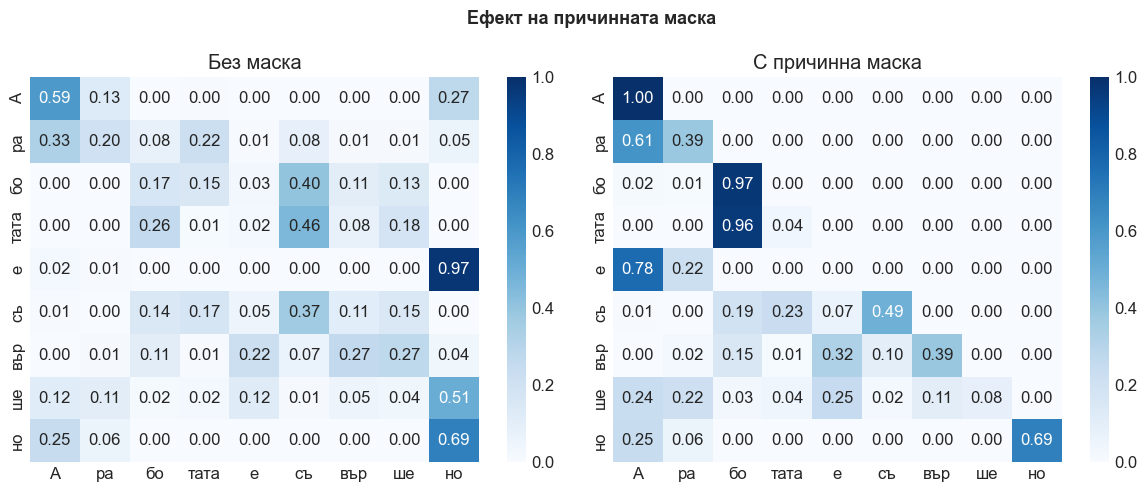

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(attn_weights.detach().numpy(), annot=True, fmt=".2f", cmap="Blues",
            xticklabels=selected_tokens, yticklabels=selected_tokens,
            ax=axes[0], vmin=0, vmax=1)
axes[0].set_title("Без маска")

sns.heatmap(attn_weights_causal.detach().numpy(), annot=True, fmt=".2f", cmap="Blues",
            xticklabels=selected_tokens, yticklabels=selected_tokens,
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("С причинна маска")

plt.suptitle("Ефект на причинната маска", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

С маската, всеки токен преразпределя вниманието си само между предходните позиции (и себе си). Първият токен може да "гледа" само себе си.

### Причинно самовнимание (CausalSelfAttention) в nanoGPT

Ето ключовите части от `CausalSelfAttention` в nanoGPT — точно това, което построихме от нулата:

```python
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        # (1) Единична проекция за Q, K, V наведнъж
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # (2) Изходна проекция W_O
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        # (3) Причинна маска — не се обучава
        self.register_buffer(
            "bias",
            torch.tril(torch.ones(config.block_size, config.block_size))
                 .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x):
        B, T, C = x.size()  # партида, дължина на редицата, d_model

        # (4) Q, K, V наведнъж → разделяме
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)

        # (5) Разделяне по глави: (B, T, C) → (B, nh, T, hs)
        hs = C // self.n_head
        k = k.view(B, T, self.n_head, hs).transpose(1, 2)
        q = q.view(B, T, self.n_head, hs).transpose(1, 2)
        v = v.view(B, T, self.n_head, hs).transpose(1, 2)

        # (6) Мащабирано скаларно произведение
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))

        # (7) Причинна маска
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))

        # (8) Softmax → тегла
        att = F.softmax(att, dim=-1)

        # (9) Претеглена сума на V
        y = att @ v  # (B, nh, T, hs)

        # (10) Конкатениране на главите + изходна проекция
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.c_proj(y)
        return y
```

**Ред по ред:**

| Ред в nanoGPT | Какво построихме ние |
|:---|:---|
| `c_attn` — проецира X в 3×d_model, после разделя на Q, K, V | `W_Q`, `W_K`, `W_V` — три отделни матрици (Блок 4) |
| `.view(...).transpose(1, 2)` — разделя по глави | `Q_heads` reshape (Блок 6) |
| `q @ k.transpose(-2, -1) * (1/√d_k)` | `scores_scaled` (Блок 4, стъпка 5) |
| `masked_fill(..., float('-inf'))` | `scores_masked` (Блок 8) |
| `att @ v` | `output = attn_weights @ V` (Блок 4, стъпка 7) |

> **Бележка:** Позиционните вграждания не са тук — те се добавят преди блоковете на вниманието в `forward()` на GPT. Ще ги разгледаме в **Лекция 5**.

---

## Блок 9: Обобщение и въпроси [Дискусия]

**Цел:** Да консолидираме наученото и да погледнем напред.

### Сравнение на подходите

| Подход | Контекст | Паралелизуемо | Дълги зависимости |
|--------|---------|:---:|---|
| MLP (Bengio) | Фиксиран прозорец | Да | Не |
| RNN | Динамичен, последователен | Не | Изчезващ градиент |
| LSTM/GRU | Динамичен, с порти | Не | По-добро, но бавно |
| **Внимание (Attention)** | **Динамичен, директен** | **Да** | **O(1) дължина на пътя** |

### Ключова формула

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V$$

Всяка стъпка — проекция в Q/K/V, мащабирано скаларно произведение, softmax, претеглена сума — видяхме директно в кода.

### Въпроси за дискусия

1. **Защо мащабираме с $\sqrt{d_k}$?** Какво се случва със стойностите на скаларното произведение при голям $d_k$?
2. **Какво се случва, ако премахнем причинната маска** в езиков модел?
3. **Внимание с множество насоки с h=1 срещу h=8** — какво се променя?
4. **Вниманието е $O(T^2)$ по изчисления** — какво означава това за редици от 100 000 токена?

### Следваща лекция

В **Лекция 5** добавяме позиционни вграждания (как моделът знае реда?), слоеве с пряко предаване (feed-forward), остатъчни връзки (residual) и нормализация на слоя (layer normalization) — и получаваме **пълен трансформаторен блок**.

---

## Обобщение

- **Изчезващият градиент** е фундаментален проблем при дълбоки вериги — градиентите намаляват експоненциално с дълбочината. RNN страда от същото при дълги редици.
- **LSTM/GRU** добавят порти за по-добър поток на градиентите, но остават последователни и бавни.
- **Самовниманието (self-attention)** позволява на всеки токен да комуникира директно с всеки друг в $O(1)$ стъпки.
- **Проекциите Q, K, V** дават гъвкавост: токенът пита (Q), рекламира (K) и предоставя (V) различни неща.
- **Вниманието с множество насоки (multi-head attention)** изпълнява множество паралелни операции на внимание, всяка научаваща различна стратегия.
- **Причинната маска** гарантира, че при езиково моделиране токените не виждат бъдещата информация.

---

## Ресурси

- Vaswani et al. 2017 — ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762) — оригиналната статия за трансформатора
- Jay Alammar — ["The Illustrated Transformer"](https://jalammar.github.io/illustrated-transformer/) — визуален преглед
- Andrej Karpathy — ["Let's build GPT"](https://www.youtube.com/watch?v=kCc8FmEb1nY) (YouTube) — имплементацията на вниманието
- [nanoGPT](https://github.com/karpathy/nanoGPT) (GitHub) — класът `CausalSelfAttention`
- 3Blue1Brown — ["Attention in transformers, visually explained"](https://www.youtube.com/watch?v=eMlx5fFNoYc)
- Bahdanau et al. 2014 — ["Neural Machine Translation by Jointly Learning to Align and Translate"](https://arxiv.org/abs/1409.0473) — оригиналният механизъм на вниманието